Day 0 start:      2024-12-02 00:00:00
First timestamp:  2024-12-02 18:40:58.296000
Last timestamp:   2025-02-08 17:23:41.984000

Experiment start: 2024-12-07 00:00:00
Experiment end:   2025-02-07 00:00:00


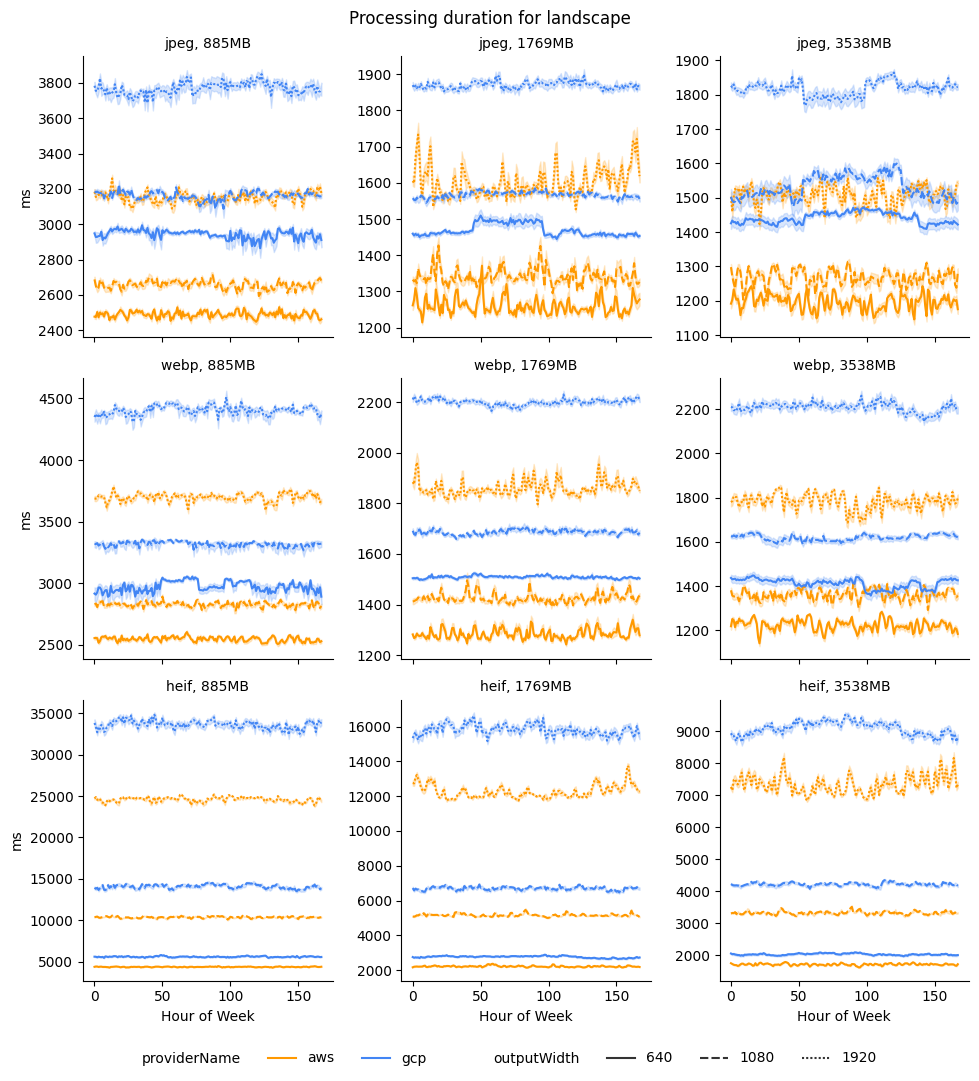

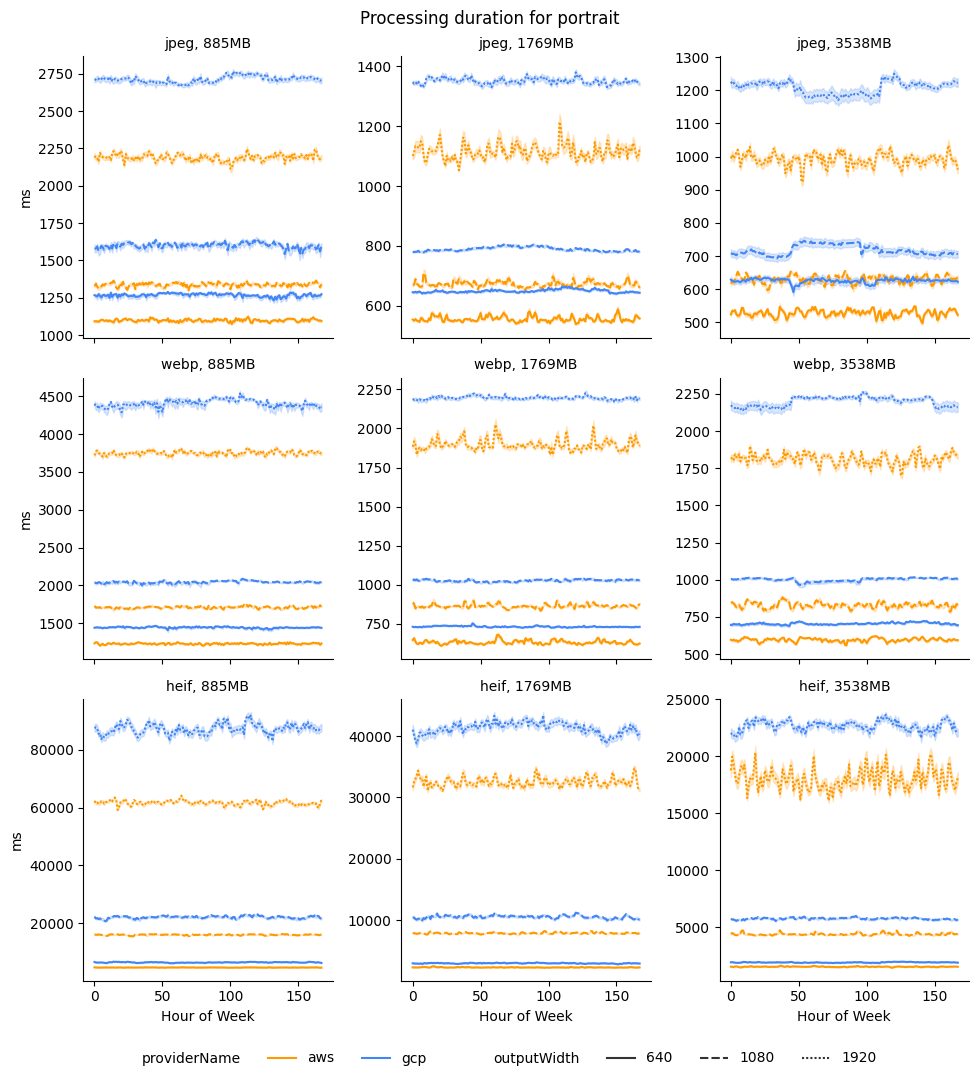

In [10]:
from datetime import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns

sns.reset_defaults()
pd.set_option('display.width', 1000)
colors = {'aws': '#ff9900', 'gcp': '#4285F4'}
pickle_df = pd.read_pickle('../stats-all-latest.pkl')
millis_in_day = 1000 * 60 * 60 * 24

# First and last executions, timestamp is in millis
min_ts = df["timestamp"].min()
max_ts = df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day

print(f'Day 0 start:      {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp:  {dt.fromtimestamp(min_ts/1000)}')
print(f'Last timestamp:   {dt.fromtimestamp(max_ts/1000)}')
print('')

# start_ts = 1733184000000 # Tue Dec 03 2024 00:00:00 GMT+0000
# end_ts   = 1738540800000 # Mon Feb 03 2025 00:00:00 GMT+0000
start_ts = 1733529600000 # Sat Dec 07 2024 00:00:00 GMT+0000
end_ts   = 1738886400000 # Fri Feb 07 2025 00:00:00 GMT+0000
print(f'Experiment start: {dt.fromtimestamp(start_ts/1000)}')
print(f'Experiment end:   {dt.fromtimestamp(end_ts/1000)}')

data = pickle_df.loc[(pickle_df['timestamp'] >= start_ts) & (pickle_df['timestamp'] < end_ts)].copy()

data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()
data["day"] = (data["timestamp"] - day_0) // millis_in_day
data["dom"] = data.index.day
data["dow"] = data.index.day_of_week
data["day_name"] = data.index.day_name()
data["day_name_short"] = data.index.strftime("%a")
data["hod"] = data.index.hour
data["moh"] = data.index.minute
data["how"] = data["dow"] * 24 + data["hod"]
data["msm"] = data.index.hour * 60 + (data.index.minute)

# only_warm = data.loc[(data['coldStart'] != 1)]
# print('day 1+, warm only', len(only_warm))

for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName)]
    g = sns.relplot(
        data=data2,
        kind='line',
        x='how',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        errorbar=('ci', 90),
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=7)
    # g.set(xticks=range(0, 32, 4), xlim=(0.5, 31.5))
    g.set_titles("{row_name}, {col_name}MB")
    # g.set_xticklabels()
    g.set_xlabels('Hour of Week')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.savefig(f'../graphs/4-duration-normalized-how-{imageName}.pdf', bbox_inches='tight') # save the plot
    plt.show()
    plt.close()

Day of Week

1051512 landscape


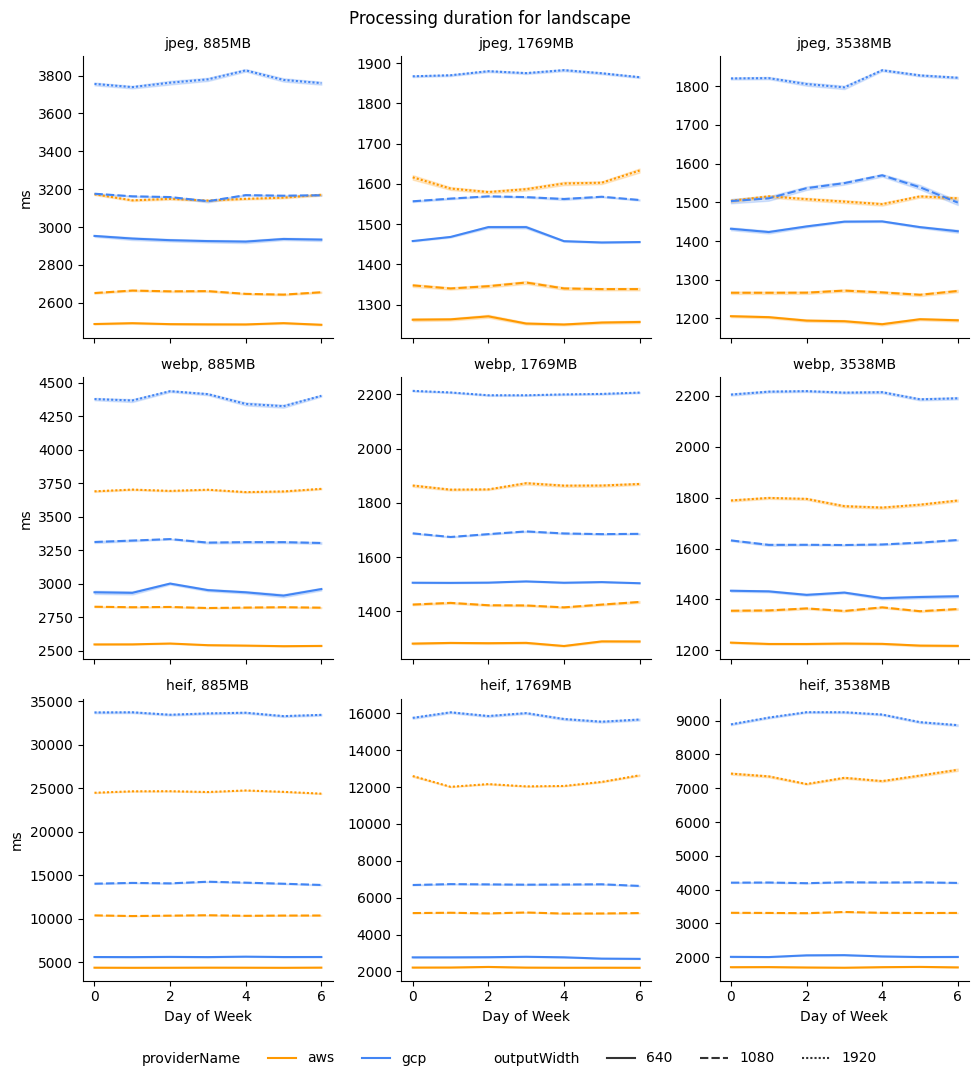

1048875 portrait


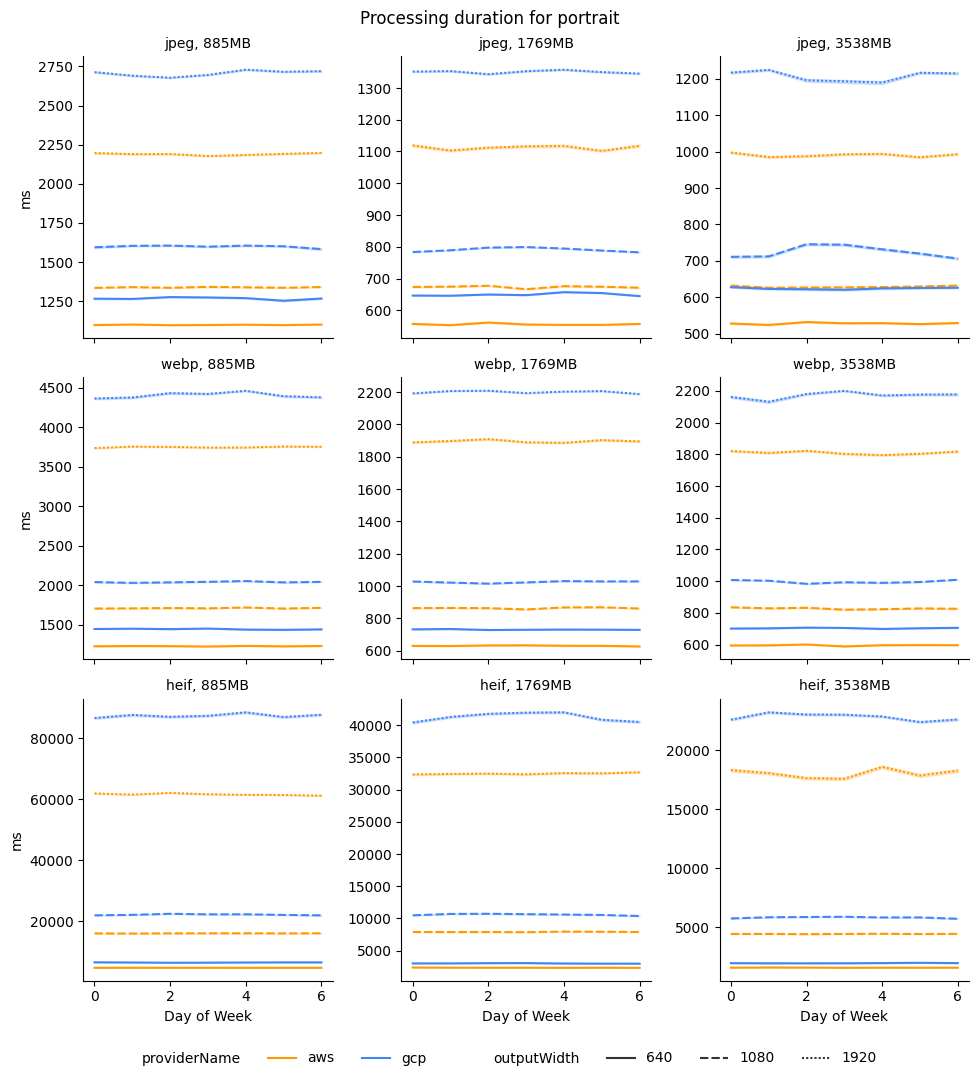

In [ ]:
for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='dow',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Day of Week')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

## Hour of week

1051512 landscape


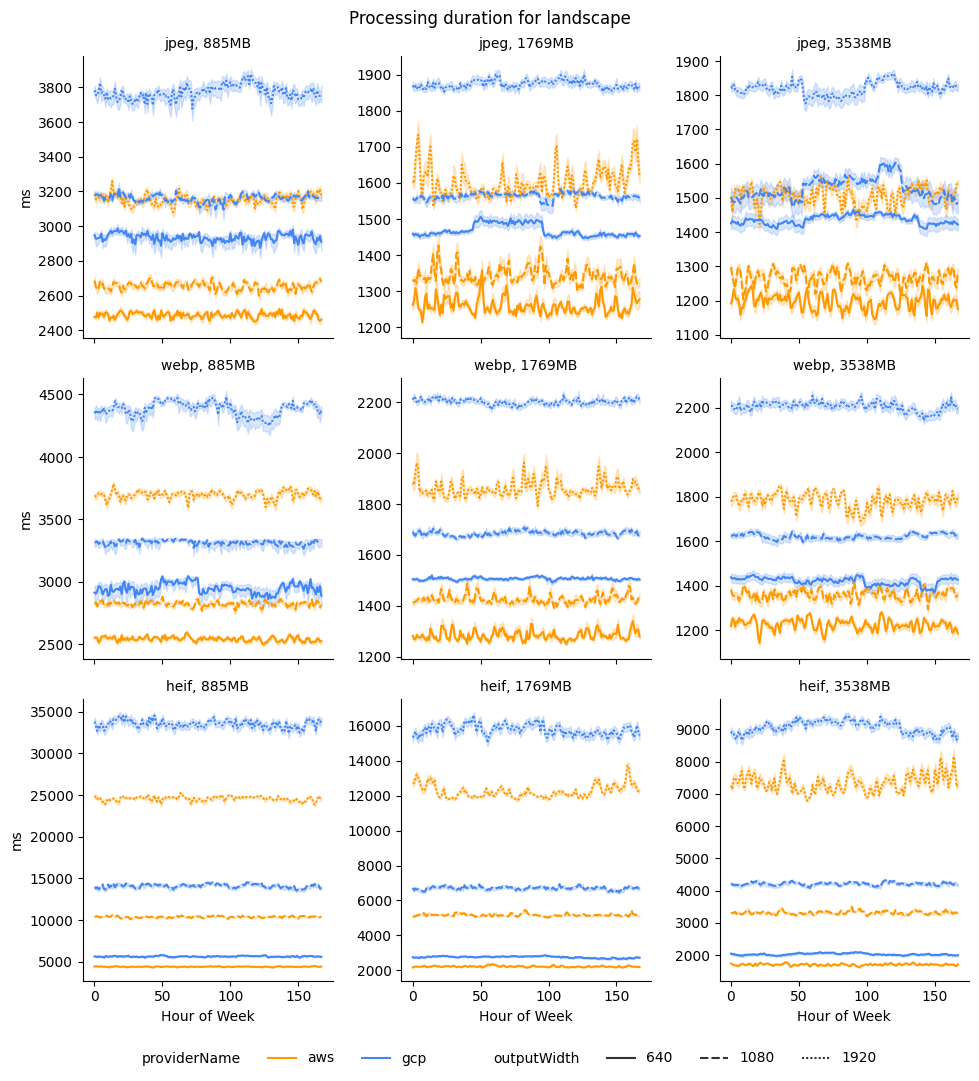

1048875 portrait


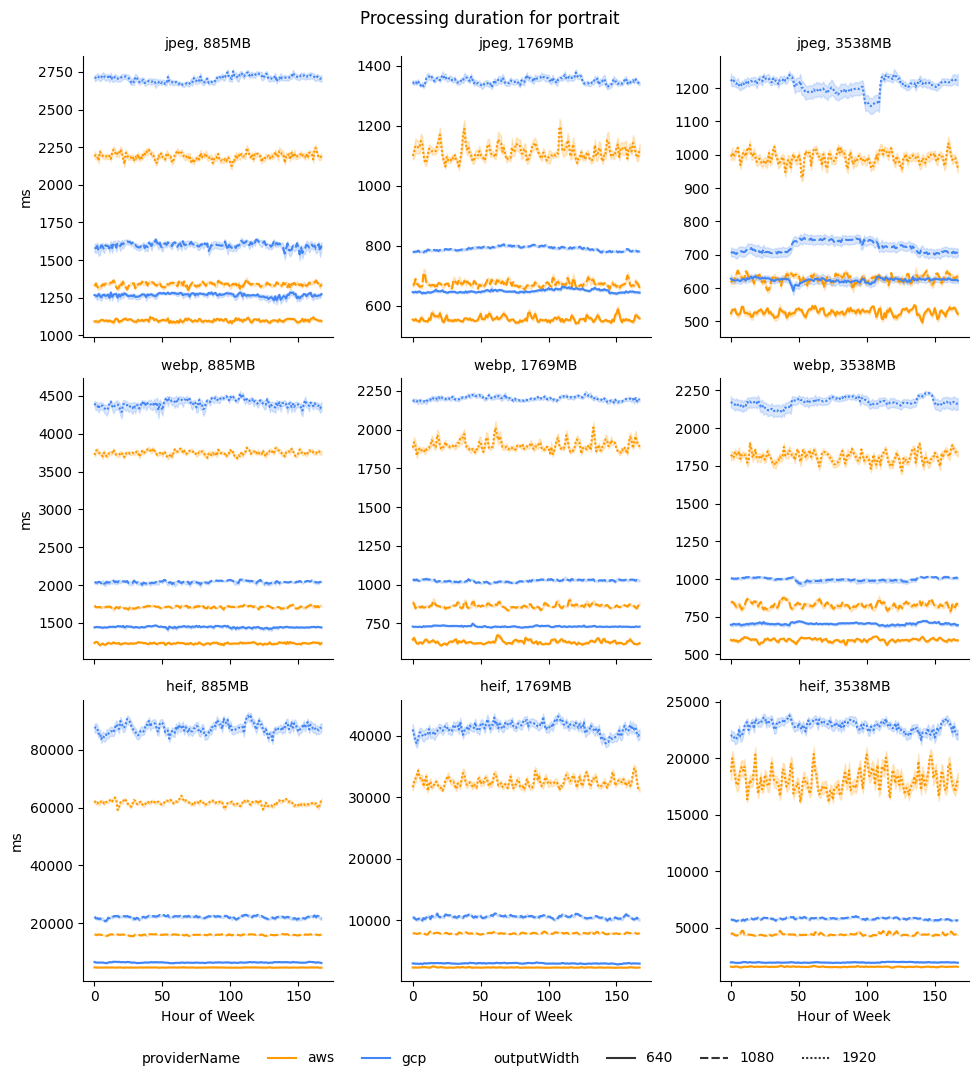

In [4]:
for imageName in ["landscape", "portrait"]:
    data2 = data.loc[(data["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='how',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Week')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

2100387
1519193 weekdays only
760802 landscape


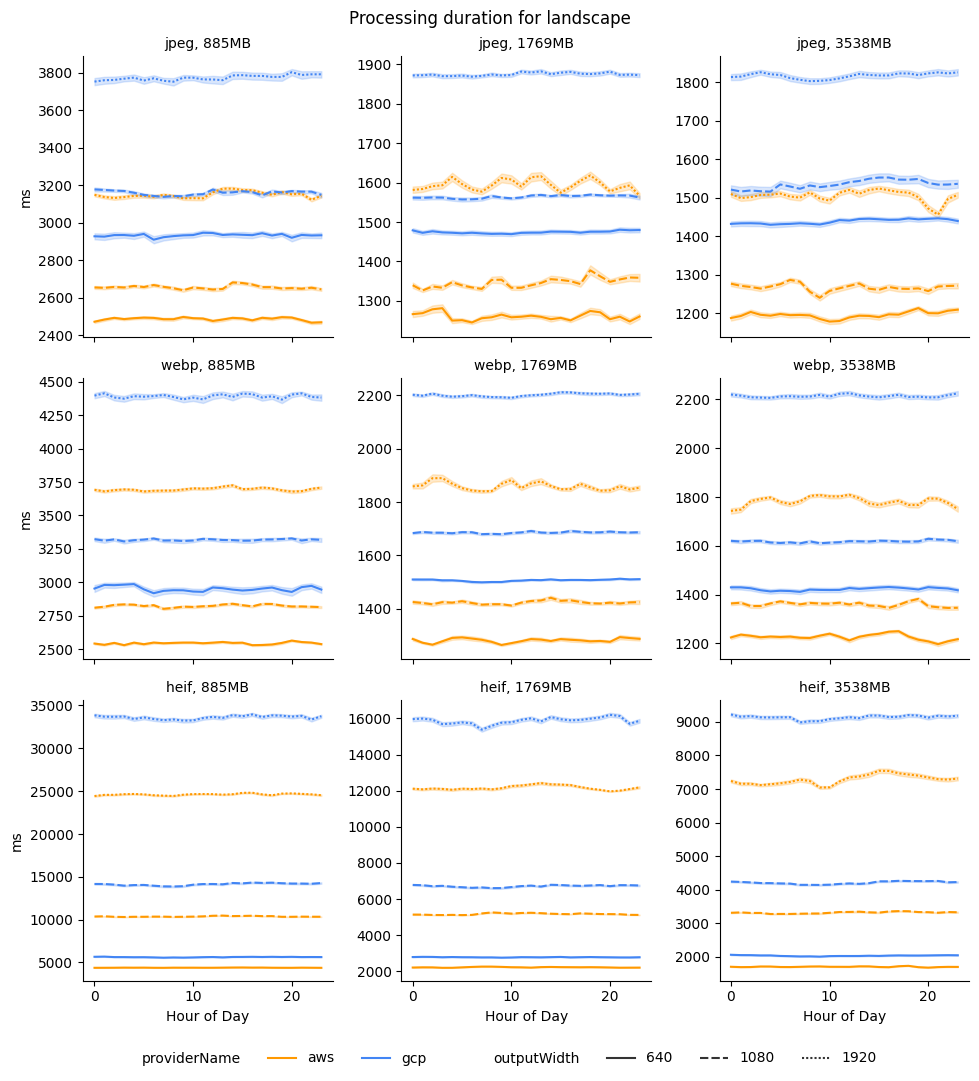

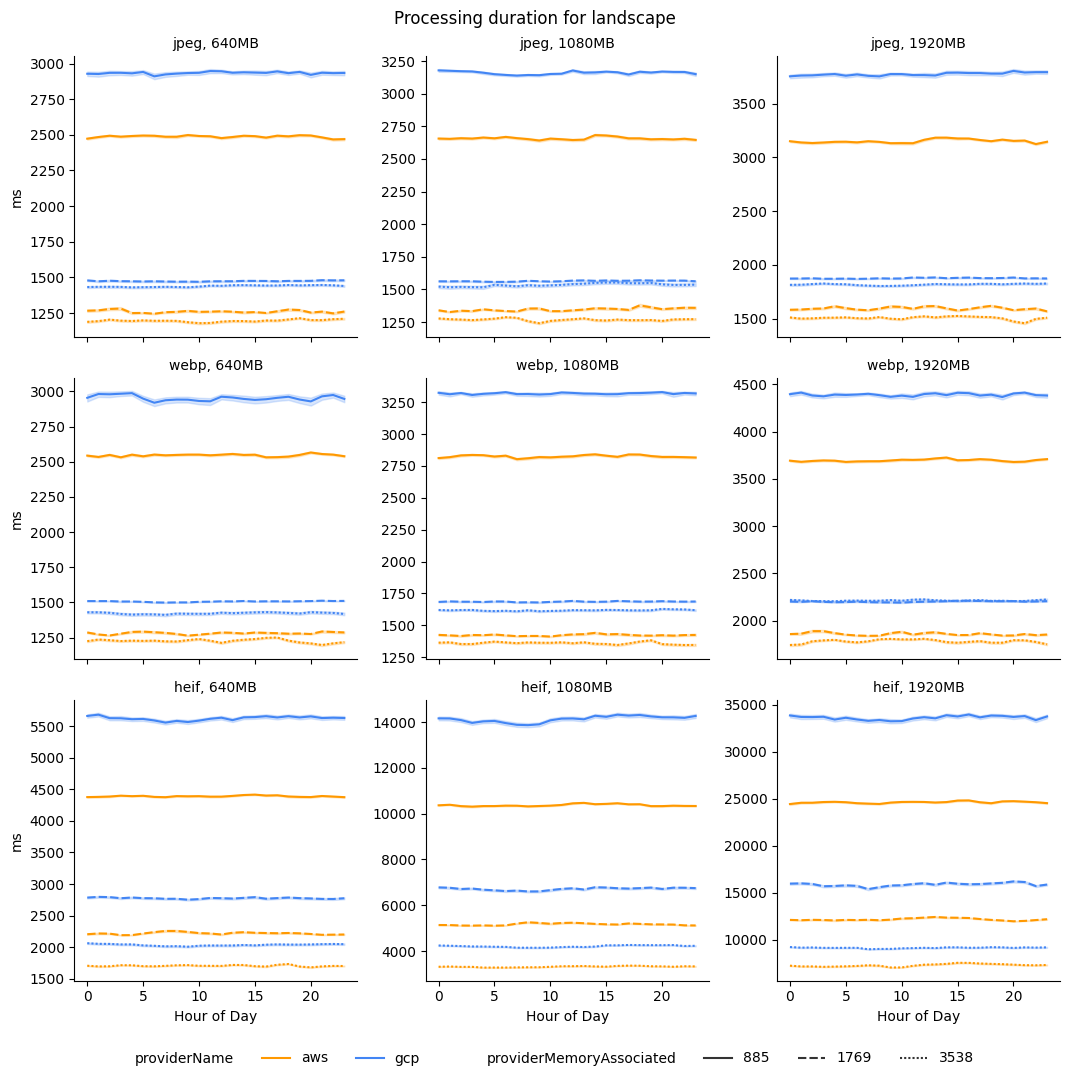

758391 portrait


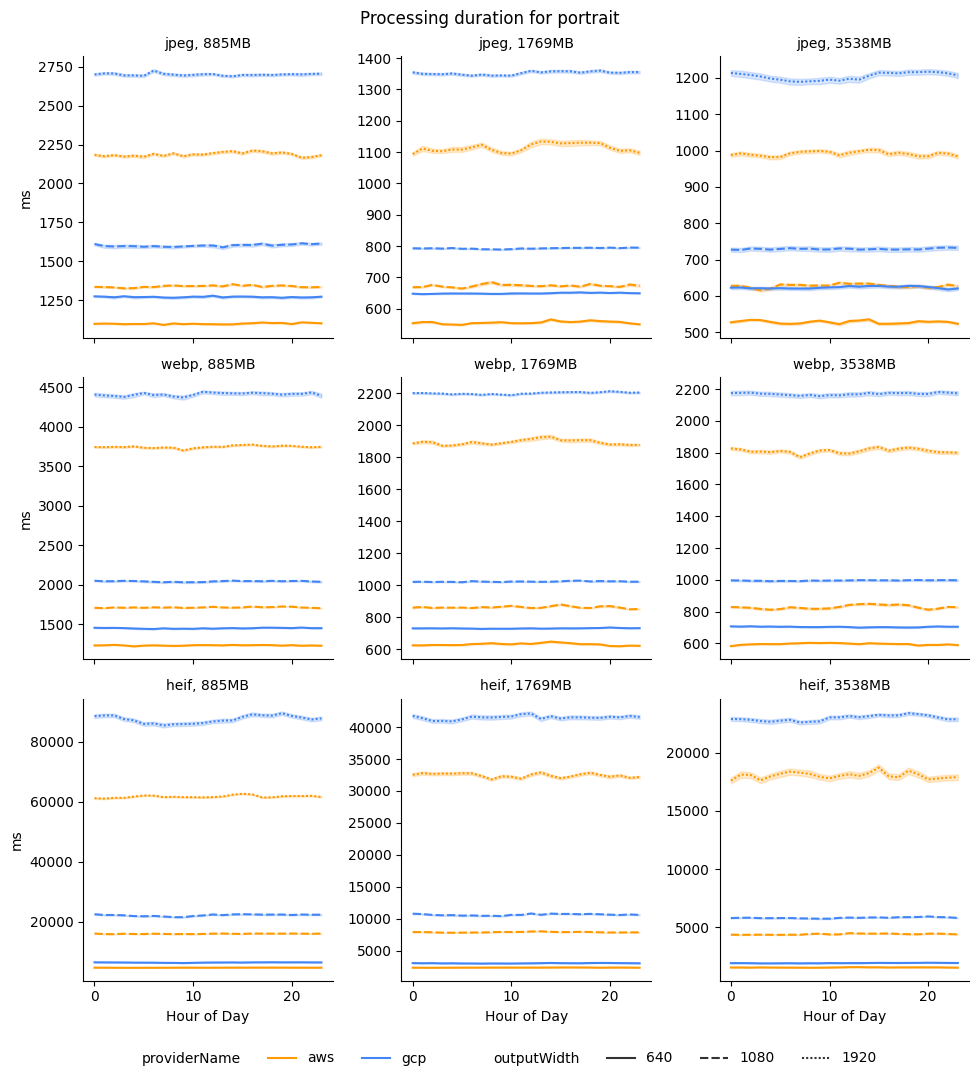

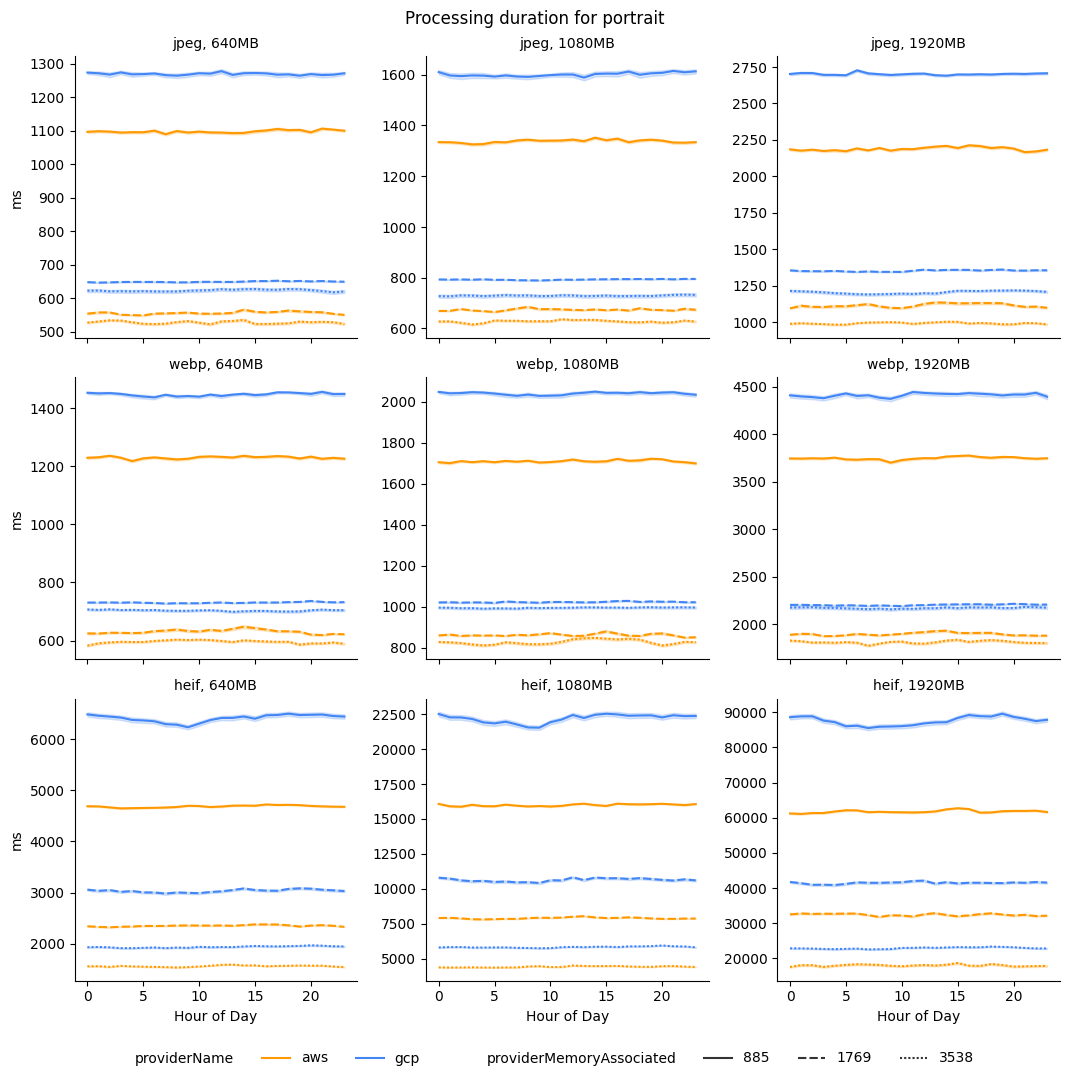

In [5]:
# remove weekends
print(len(data))
weekdays_only = data.loc[(data["dow"] != 5) & (data["dow"] != 6)]
print(len(weekdays_only), 'weekdays only')

for imageName in ["landscape", "portrait"]:
    data2 = weekdays_only.loc[(weekdays_only["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='hod',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

    g = sns.relplot(
        data=data2,
        kind='line',
        x='hod',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='outputWidth',
        style='providerMemoryAssociated',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Hour of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()

Minute since midnight

2100387
1519193 weekdays only
760802 landscape


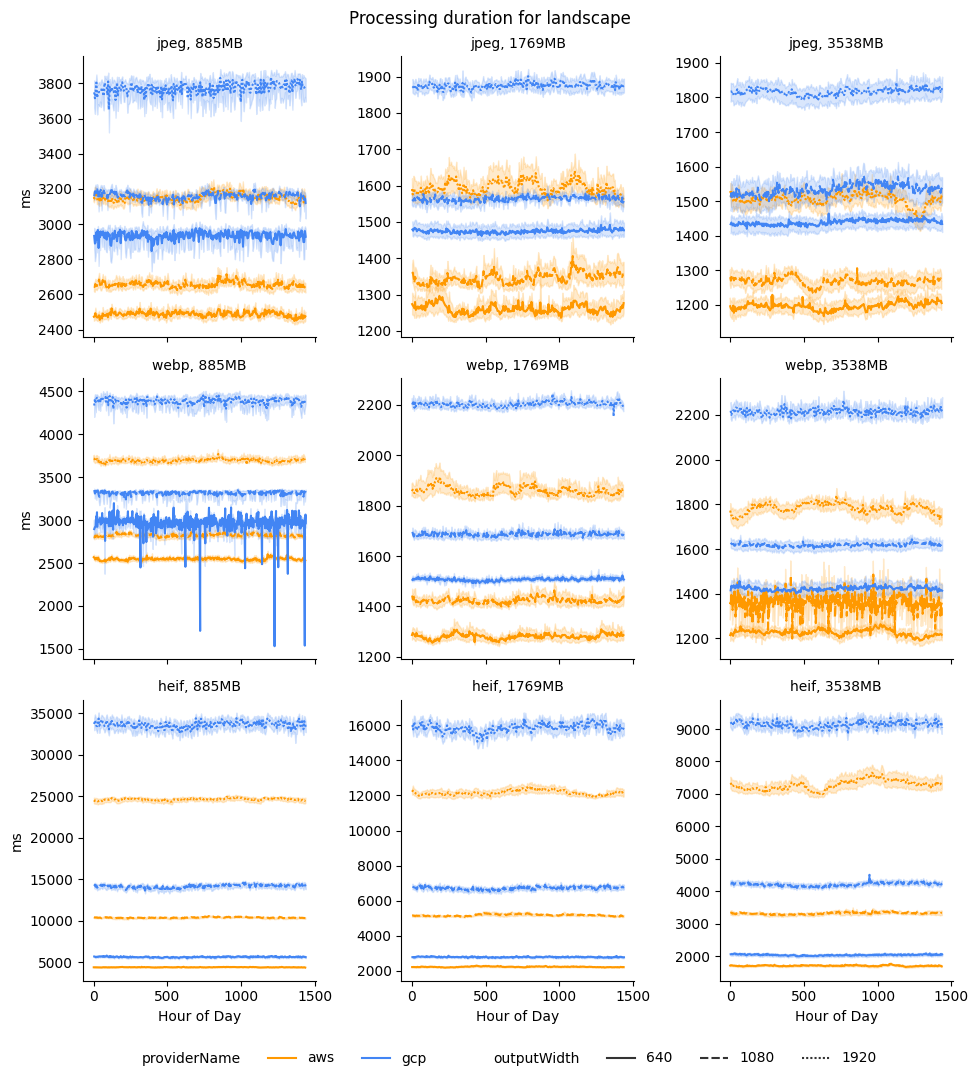

758391 portrait


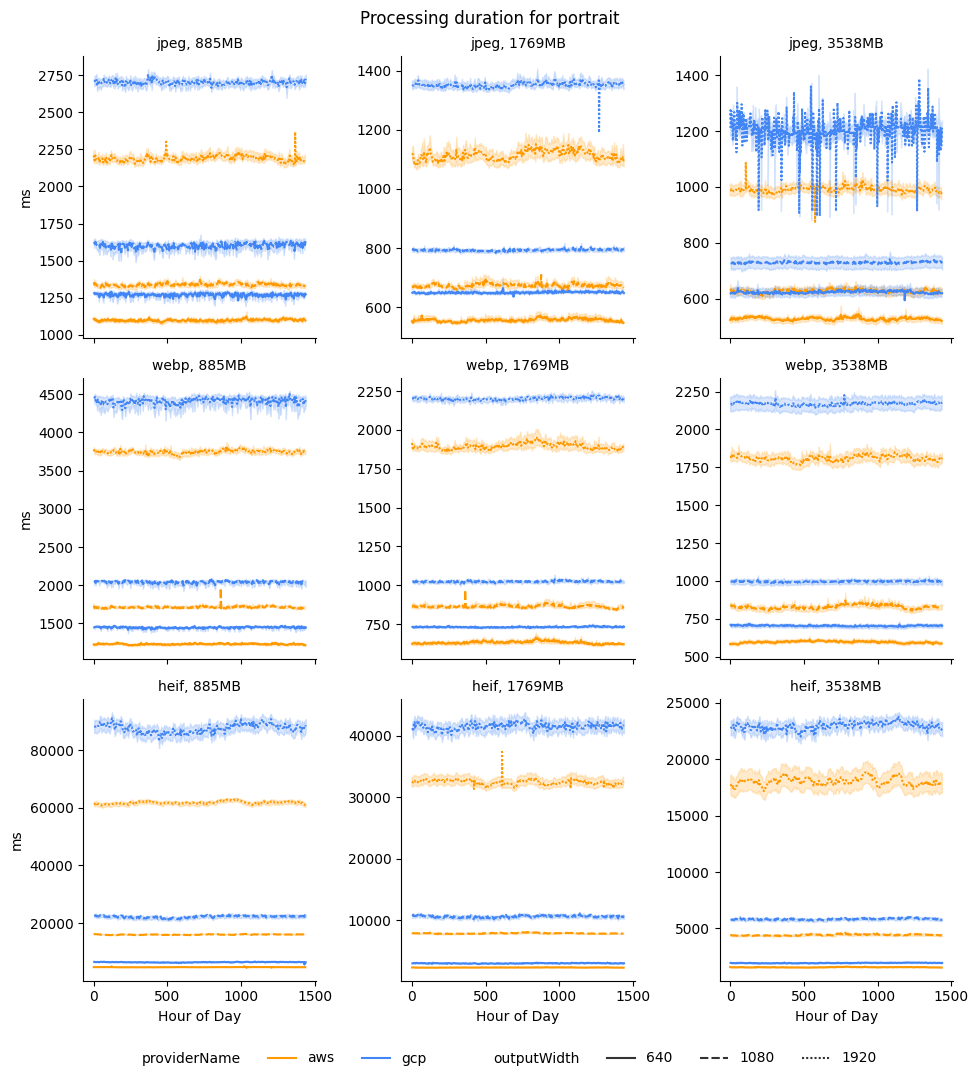

In [6]:
# remove weekends
print(len(data))
weekdays_only = data.loc[(data["dow"] != 5) & (data["dow"] != 6)]
print(len(weekdays_only), 'weekdays only')

for imageName in ["landscape", "portrait"]:
    data2 = weekdays_only.loc[(weekdays_only["imageName"] == imageName)]
    print(len(data2), imageName)

    g = sns.relplot(
        data=data2,
        kind='line',
        x='msm',
        y='durationProcessingMs',
        hue='providerName',   # Keep providerName for color differentiation
        palette=colors,       # Use the defined colors
        row='outputFormat',   # Separate rows for each provider
        col='providerMemoryAssociated',
        style='outputWidth',
        row_order=['jpeg', 'webp', 'heif'],
        aspect=0.8,
        height=3.5,
        # facet_kws={'sharey': 'row'},
        facet_kws={'sharey': False},
    )

    sns.move_legend(g, loc='upper center', bbox_to_anchor=(0.5, 0), title='', ncol=8)
    g.set_titles("{row_name}, {col_name}MB")
    g.set_xlabels('Minute of Day')
    g.set_ylabels('ms')
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    plt.show()